# Part 1: Helping functions and data loading

In [3]:
# Do not modify this cell, this is only for plotting the clusters
# NOTE: I modified the cluster to plot centers.
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, centers=None, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")

    if centers is not None and centers.any():
        ax.scatter(centers[:,0], centers[:,1], s=18, marker="D", c="k", alpha=0.9, label="center")

    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.show()

In [4]:
from IPython.display import display
from IPython.display import Markdown

def report(string):
    display(Markdown(string))

class Table:
    def tableHeader(self):
        doc = "| EPS | MIN_POINTS | density | #Clusters | #Noise |\n"
        doc += "| --- | --- | --- | --- | --- |\n"
        return doc

    def __init__(self):
        self.prev_algo = None
        self.prev_hyper = None
        self.prev_value = None
        self.doc = self.tableHeader()

    def addRow(self, eps=None, minPoints=None, density=None, num_clusters=None, num_noise=None):
        rows = ""
        if density is None:
           density = (minPoints/(np.pi * eps**2))
        rows += f"| {eps:.4g} | {minPoints} | {density:.4g} | {num_clusters} | {num_noise} |\n"
        self.doc = self.doc + rows
        return self

    def report(self):
        report(self.doc)


enable_debug = False

def debug(string):
    if (enable_debug):
        print(string)


# https://xkcd.com/221/ - 4 is overused
random_seed = 221


In [5]:
# loading data
import numpy as np

# part1_data.npz contains X.npy and Y.npy. the array indexing loads the individual file.
X = np.load("part1_data.npz")["X"]

# Part 2: Clustering

## K-means experiments


### Hyperparameter Discovery


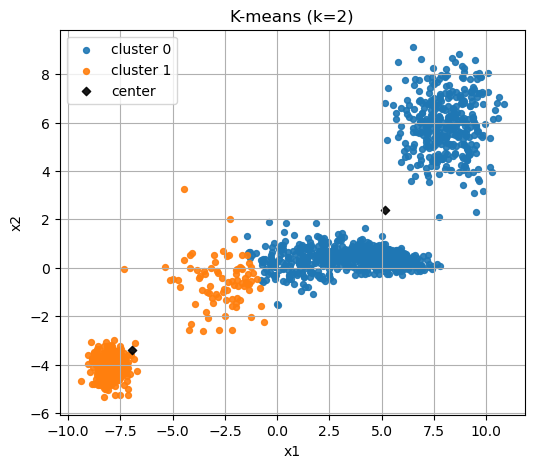

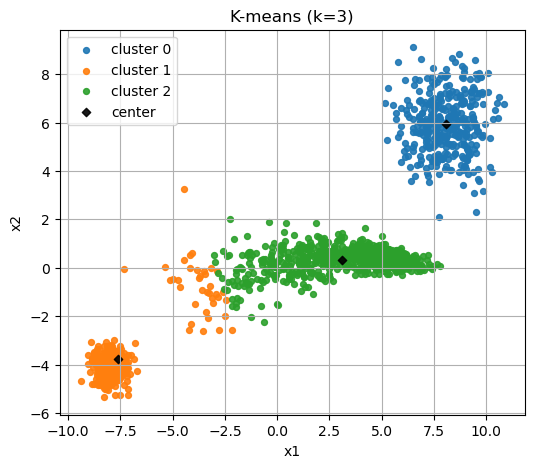

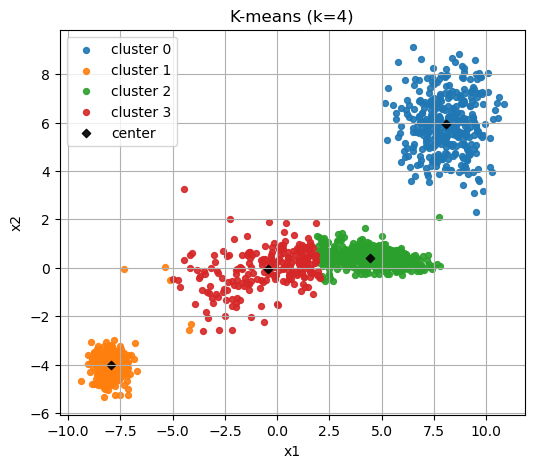

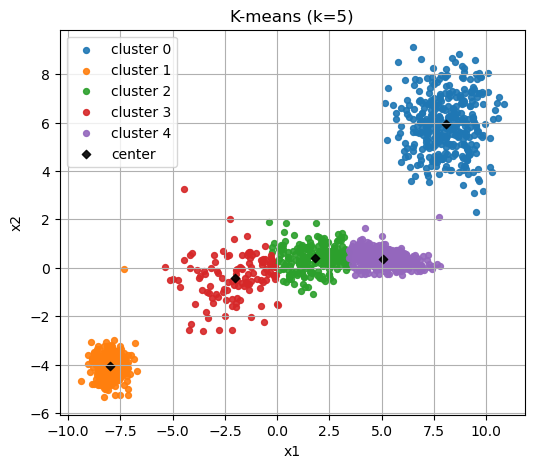

In [6]:
from sklearn.cluster import KMeans

# Number of clusters
for K in [ 2,3,4,5] :
    # K = 10

    # Fit K-means and get labels
    km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    # ploting data
    plot_clustering_result(X, labels, centers=centers, title=f"K-means (k={K})")


### K-means Answers

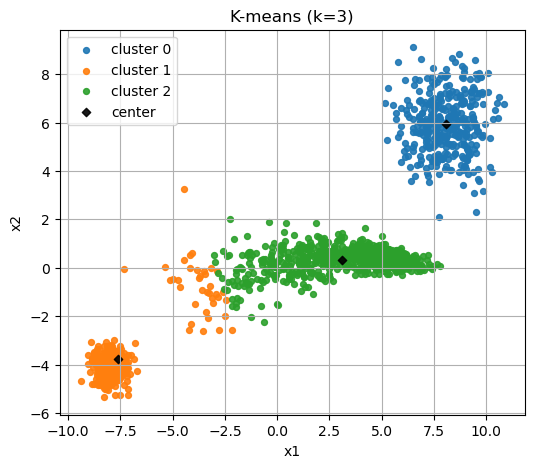

In [7]:
from sklearn.cluster import KMeans

# Number of clusters
for K in [3] :
    # Fit K-means and get labels
    km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    # ploting data
    plot_clustering_result(X, labels, centers=centers, title=f"K-means (k={K})")


The value for K which best matches the visible clusters is 3. This value for K results in the central cluster being blended with the bottom left cluster. K-means creates circular clusters, and the central cluster cannot be grown any more without taking members from the top-right cluster. This requires the bottom left cluster to grow to take the less dense component of the central cluster.

However, the value of K which is the most useful is 5. It splits the central cluster into 3 clusters, isolating them from the bottom left and top right. If we are using K-means to apply a treatment to a group, we can apply the same treatment to the central 3 clusters and have a result which is more accurate than K=3. We increase the number of clusters to make up for the central cluster's non-circular shape.

## DBSCAN experiments


### Hyperparameter Search


In [8]:
# Minimal Noise Hyperparameter Search.

import numpy as np
from sklearn.cluster import DBSCAN


# Hyperparameter searching is best done computationally. So, compute away!
hyperResults = Table()

# search all eps from 0.1..2 in 0.1 steps
for eps in np.arange(0.1, 2., 0.1):
    # search all min_points in 3..50
    for min_points in range(3, 50):
        labels = DBSCAN(eps=eps, min_samples=min_points).fit_predict(X)
        num_noise = (labels==-1).sum()
        num_clusters=len(set(labels) - {-1})
        # We know num_clusters is 3, so use that.
        # It is a big table, only output reasonable values for selection.
        if num_clusters == 3 and num_noise < 5:
            hyperResults.addRow(eps=eps, minPoints=min_points, num_clusters=num_clusters, num_noise=num_noise)

hyperResults.report()

| EPS | MIN_POINTS | density | #Clusters | #Noise |
| --- | --- | --- | --- | --- |
| 0.8 | 3 | 1.492 | 3 | 4 |
| 0.9 | 3 | 1.179 | 3 | 3 |
| 0.9 | 4 | 1.572 | 3 | 3 |
| 0.9 | 5 | 1.965 | 3 | 3 |
| 0.9 | 6 | 2.358 | 3 | 3 |
| 0.9 | 7 | 2.751 | 3 | 4 |
| 1 | 3 | 0.9549 | 3 | 3 |
| 1 | 4 | 1.273 | 3 | 3 |
| 1 | 5 | 1.592 | 3 | 3 |
| 1 | 6 | 1.91 | 3 | 3 |
| 1 | 7 | 2.228 | 3 | 4 |
| 1.1 | 3 | 0.7892 | 3 | 3 |
| 1.1 | 4 | 1.052 | 3 | 3 |
| 1.1 | 5 | 1.315 | 3 | 3 |
| 1.1 | 6 | 1.578 | 3 | 3 |
| 1.1 | 7 | 1.841 | 3 | 3 |
| 1.1 | 8 | 2.105 | 3 | 3 |
| 1.1 | 9 | 2.368 | 3 | 4 |
| 1.1 | 10 | 2.631 | 3 | 4 |
| 1.1 | 11 | 2.894 | 3 | 4 |
| 1.2 | 3 | 0.6631 | 3 | 3 |
| 1.2 | 4 | 0.8842 | 3 | 3 |
| 1.2 | 5 | 1.105 | 3 | 3 |
| 1.2 | 6 | 1.326 | 3 | 3 |
| 1.2 | 7 | 1.547 | 3 | 3 |
| 1.2 | 8 | 1.768 | 3 | 3 |
| 1.2 | 9 | 1.989 | 3 | 3 |
| 1.2 | 10 | 2.21 | 3 | 3 |
| 1.2 | 11 | 2.432 | 3 | 3 |
| 1.2 | 12 | 2.653 | 3 | 3 |
| 1.2 | 13 | 2.874 | 3 | 4 |
| 1.3 | 3 | 0.565 | 3 | 3 |
| 1.3 | 4 | 0.7534 | 3 | 3 |
| 1.3 | 5 | 0.9417 | 3 | 3 |
| 1.3 | 6 | 1.13 | 3 | 3 |
| 1.3 | 7 | 1.318 | 3 | 3 |
| 1.3 | 8 | 1.507 | 3 | 3 |
| 1.3 | 9 | 1.695 | 3 | 3 |
| 1.3 | 10 | 1.883 | 3 | 3 |
| 1.3 | 11 | 2.072 | 3 | 3 |
| 1.3 | 12 | 2.26 | 3 | 3 |
| 1.3 | 13 | 2.449 | 3 | 3 |
| 1.3 | 14 | 2.637 | 3 | 3 |
| 1.3 | 15 | 2.825 | 3 | 3 |
| 1.3 | 16 | 3.014 | 3 | 3 |
| 1.3 | 17 | 3.202 | 3 | 3 |
| 1.3 | 18 | 3.39 | 3 | 4 |
| 1.3 | 19 | 3.579 | 3 | 4 |
| 1.3 | 20 | 3.767 | 3 | 4 |
| 1.4 | 3 | 0.4872 | 3 | 3 |
| 1.4 | 4 | 0.6496 | 3 | 3 |
| 1.4 | 5 | 0.812 | 3 | 3 |
| 1.4 | 6 | 0.9744 | 3 | 3 |
| 1.4 | 7 | 1.137 | 3 | 3 |
| 1.4 | 8 | 1.299 | 3 | 3 |
| 1.4 | 9 | 1.462 | 3 | 3 |
| 1.4 | 10 | 1.624 | 3 | 3 |
| 1.4 | 11 | 1.786 | 3 | 3 |
| 1.4 | 12 | 1.949 | 3 | 3 |
| 1.4 | 13 | 2.111 | 3 | 3 |
| 1.4 | 14 | 2.274 | 3 | 3 |
| 1.4 | 15 | 2.436 | 3 | 3 |
| 1.4 | 16 | 2.598 | 3 | 3 |
| 1.4 | 17 | 2.761 | 3 | 3 |
| 1.4 | 18 | 2.923 | 3 | 3 |
| 1.4 | 19 | 3.086 | 3 | 3 |
| 1.4 | 20 | 3.248 | 3 | 3 |
| 1.4 | 21 | 3.41 | 3 | 3 |
| 1.4 | 22 | 3.573 | 3 | 3 |
| 1.4 | 23 | 3.735 | 3 | 4 |
| 1.5 | 3 | 0.4244 | 3 | 3 |
| 1.5 | 4 | 0.5659 | 3 | 3 |
| 1.5 | 5 | 0.7074 | 3 | 3 |
| 1.5 | 6 | 0.8488 | 3 | 3 |
| 1.5 | 7 | 0.9903 | 3 | 3 |
| 1.5 | 8 | 1.132 | 3 | 3 |
| 1.5 | 9 | 1.273 | 3 | 3 |
| 1.5 | 10 | 1.415 | 3 | 3 |
| 1.5 | 11 | 1.556 | 3 | 3 |
| 1.5 | 12 | 1.698 | 3 | 3 |
| 1.5 | 13 | 1.839 | 3 | 3 |
| 1.5 | 14 | 1.981 | 3 | 3 |
| 1.5 | 15 | 2.122 | 3 | 3 |
| 1.5 | 16 | 2.264 | 3 | 3 |
| 1.5 | 17 | 2.405 | 3 | 3 |
| 1.5 | 18 | 2.546 | 3 | 3 |
| 1.5 | 19 | 2.688 | 3 | 3 |
| 1.5 | 20 | 2.829 | 3 | 3 |
| 1.5 | 21 | 2.971 | 3 | 3 |
| 1.5 | 22 | 3.112 | 3 | 3 |
| 1.5 | 23 | 3.254 | 3 | 3 |
| 1.5 | 24 | 3.395 | 3 | 4 |
| 1.5 | 25 | 3.537 | 3 | 4 |
| 1.5 | 26 | 3.678 | 3 | 4 |
| 1.6 | 3 | 0.373 | 3 | 2 |
| 1.6 | 4 | 0.4974 | 3 | 2 |
| 1.6 | 5 | 0.6217 | 3 | 2 |
| 1.6 | 6 | 0.746 | 3 | 2 |
| 1.6 | 7 | 0.8704 | 3 | 2 |
| 1.6 | 8 | 0.9947 | 3 | 2 |
| 1.6 | 9 | 1.119 | 3 | 2 |
| 1.6 | 10 | 1.243 | 3 | 2 |
| 1.6 | 11 | 1.368 | 3 | 2 |
| 1.6 | 12 | 1.492 | 3 | 2 |
| 1.6 | 13 | 1.616 | 3 | 2 |
| 1.6 | 14 | 1.741 | 3 | 2 |
| 1.6 | 15 | 1.865 | 3 | 2 |
| 1.6 | 16 | 1.989 | 3 | 2 |
| 1.6 | 17 | 2.114 | 3 | 2 |
| 1.6 | 18 | 2.238 | 3 | 2 |
| 1.6 | 19 | 2.362 | 3 | 2 |
| 1.6 | 20 | 2.487 | 3 | 2 |
| 1.6 | 21 | 2.611 | 3 | 2 |
| 1.6 | 22 | 2.735 | 3 | 2 |
| 1.6 | 23 | 2.86 | 3 | 2 |
| 1.6 | 24 | 2.984 | 3 | 2 |
| 1.6 | 25 | 3.108 | 3 | 2 |
| 1.6 | 26 | 3.233 | 3 | 2 |
| 1.6 | 27 | 3.357 | 3 | 2 |
| 1.6 | 28 | 3.482 | 3 | 2 |
| 1.6 | 29 | 3.606 | 3 | 2 |
| 1.6 | 30 | 3.73 | 3 | 2 |
| 1.6 | 31 | 3.855 | 3 | 2 |
| 1.6 | 32 | 3.979 | 3 | 2 |
| 1.6 | 33 | 4.103 | 3 | 2 |
| 1.6 | 34 | 4.228 | 3 | 2 |
| 1.6 | 35 | 4.352 | 3 | 3 |
| 1.6 | 36 | 4.476 | 3 | 3 |
| 1.6 | 37 | 4.601 | 3 | 3 |
| 1.6 | 38 | 4.725 | 3 | 3 |
| 1.6 | 39 | 4.849 | 3 | 3 |
| 1.6 | 40 | 4.974 | 3 | 3 |
| 1.6 | 41 | 5.098 | 3 | 4 |
| 1.7 | 4 | 0.4406 | 3 | 2 |
| 1.7 | 5 | 0.5507 | 3 | 2 |
| 1.7 | 6 | 0.6609 | 3 | 2 |
| 1.7 | 7 | 0.771 | 3 | 2 |
| 1.7 | 8 | 0.8811 | 3 | 2 |
| 1.7 | 9 | 0.9913 | 3 | 2 |
| 1.7 | 10 | 1.101 | 3 | 2 |
| 1.7 | 11 | 1.212 | 3 | 2 |
| 1.7 | 12 | 1.322 | 3 | 2 |
| 1.7 | 13 | 1.432 | 3 | 2 |
| 1.7 | 14 | 1.542 | 3 | 2 |
| 1.7 | 15 | 1.652 | 3 | 2 |
| 1.7 | 16 | 1.762 | 3 | 2 |
| 1.7 | 17 | 1.872 | 3 | 2 |
| 1.7 | 18 | 1.983 | 3 | 2 |
| 1.7 | 19 | 2.093 | 3 | 2 |
| 1.7 | 20 | 2.203 | 3 | 2 |
| 1.7 | 21 | 2.313 | 3 | 2 |
| 1.7 | 22 | 2.423 | 3 | 2 |
| 1.7 | 23 | 2.533 | 3 | 2 |
| 1.7 | 24 | 2.643 | 3 | 2 |
| 1.7 | 25 | 2.754 | 3 | 2 |
| 1.7 | 26 | 2.864 | 3 | 2 |
| 1.7 | 27 | 2.974 | 3 | 2 |
| 1.7 | 28 | 3.084 | 3 | 2 |
| 1.7 | 29 | 3.194 | 3 | 2 |
| 1.7 | 30 | 3.304 | 3 | 2 |
| 1.7 | 31 | 3.414 | 3 | 2 |
| 1.7 | 32 | 3.525 | 3 | 2 |
| 1.7 | 33 | 3.635 | 3 | 2 |
| 1.7 | 34 | 3.745 | 3 | 2 |
| 1.7 | 35 | 3.855 | 3 | 2 |
| 1.7 | 36 | 3.965 | 3 | 2 |
| 1.7 | 37 | 4.075 | 3 | 3 |
| 1.7 | 38 | 4.185 | 3 | 3 |
| 1.7 | 39 | 4.296 | 3 | 3 |
| 1.7 | 40 | 4.406 | 3 | 3 |
| 1.7 | 41 | 4.516 | 3 | 3 |
| 1.7 | 42 | 4.626 | 3 | 3 |
| 1.7 | 43 | 4.736 | 3 | 3 |
| 1.7 | 44 | 4.846 | 3 | 3 |
| 1.7 | 45 | 4.956 | 3 | 3 |
| 1.7 | 46 | 5.067 | 3 | 4 |
| 1.8 | 9 | 0.8842 | 3 | 2 |
| 1.8 | 10 | 0.9824 | 3 | 2 |
| 1.8 | 11 | 1.081 | 3 | 2 |
| 1.8 | 12 | 1.179 | 3 | 2 |
| 1.8 | 13 | 1.277 | 3 | 2 |
| 1.8 | 14 | 1.375 | 3 | 2 |
| 1.8 | 15 | 1.474 | 3 | 2 |
| 1.8 | 16 | 1.572 | 3 | 2 |
| 1.8 | 17 | 1.67 | 3 | 2 |
| 1.8 | 18 | 1.768 | 3 | 2 |
| 1.8 | 19 | 1.867 | 3 | 2 |
| 1.8 | 20 | 1.965 | 3 | 2 |
| 1.8 | 21 | 2.063 | 3 | 2 |
| 1.8 | 22 | 2.161 | 3 | 2 |
| 1.8 | 23 | 2.26 | 3 | 2 |
| 1.8 | 24 | 2.358 | 3 | 2 |
| 1.8 | 25 | 2.456 | 3 | 2 |
| 1.8 | 26 | 2.554 | 3 | 2 |
| 1.8 | 27 | 2.653 | 3 | 2 |
| 1.8 | 28 | 2.751 | 3 | 2 |
| 1.8 | 29 | 2.849 | 3 | 2 |
| 1.8 | 30 | 2.947 | 3 | 2 |
| 1.8 | 31 | 3.046 | 3 | 2 |
| 1.8 | 32 | 3.144 | 3 | 2 |
| 1.8 | 33 | 3.242 | 3 | 2 |
| 1.8 | 34 | 3.34 | 3 | 2 |
| 1.8 | 35 | 3.439 | 3 | 2 |
| 1.8 | 36 | 3.537 | 3 | 2 |
| 1.8 | 37 | 3.635 | 3 | 2 |
| 1.8 | 38 | 3.733 | 3 | 2 |
| 1.8 | 39 | 3.832 | 3 | 2 |
| 1.8 | 40 | 3.93 | 3 | 2 |
| 1.8 | 41 | 4.028 | 3 | 2 |
| 1.8 | 42 | 4.126 | 3 | 2 |
| 1.8 | 43 | 4.224 | 3 | 2 |
| 1.8 | 44 | 4.323 | 3 | 2 |
| 1.8 | 45 | 4.421 | 3 | 2 |
| 1.8 | 46 | 4.519 | 3 | 2 |
| 1.8 | 47 | 4.617 | 3 | 3 |
| 1.8 | 48 | 4.716 | 3 | 3 |
| 1.8 | 49 | 4.814 | 3 | 3 |
| 1.9 | 10 | 0.8817 | 3 | 2 |
| 1.9 | 11 | 0.9699 | 3 | 2 |
| 1.9 | 12 | 1.058 | 3 | 2 |
| 1.9 | 13 | 1.146 | 3 | 2 |
| 1.9 | 14 | 1.234 | 3 | 2 |
| 1.9 | 15 | 1.323 | 3 | 2 |
| 1.9 | 16 | 1.411 | 3 | 2 |
| 1.9 | 17 | 1.499 | 3 | 2 |
| 1.9 | 18 | 1.587 | 3 | 2 |
| 1.9 | 19 | 1.675 | 3 | 2 |
| 1.9 | 20 | 1.763 | 3 | 2 |
| 1.9 | 21 | 1.852 | 3 | 2 |
| 1.9 | 22 | 1.94 | 3 | 2 |
| 1.9 | 23 | 2.028 | 3 | 2 |
| 1.9 | 24 | 2.116 | 3 | 2 |
| 1.9 | 25 | 2.204 | 3 | 2 |
| 1.9 | 26 | 2.293 | 3 | 2 |
| 1.9 | 27 | 2.381 | 3 | 2 |
| 1.9 | 28 | 2.469 | 3 | 2 |
| 1.9 | 29 | 2.557 | 3 | 2 |
| 1.9 | 30 | 2.645 | 3 | 2 |
| 1.9 | 31 | 2.733 | 3 | 2 |
| 1.9 | 32 | 2.822 | 3 | 2 |
| 1.9 | 33 | 2.91 | 3 | 2 |
| 1.9 | 34 | 2.998 | 3 | 2 |
| 1.9 | 35 | 3.086 | 3 | 2 |
| 1.9 | 36 | 3.174 | 3 | 2 |
| 1.9 | 37 | 3.262 | 3 | 2 |
| 1.9 | 38 | 3.351 | 3 | 2 |
| 1.9 | 39 | 3.439 | 3 | 2 |
| 1.9 | 40 | 3.527 | 3 | 2 |
| 1.9 | 41 | 3.615 | 3 | 2 |
| 1.9 | 42 | 3.703 | 3 | 2 |
| 1.9 | 43 | 3.792 | 3 | 2 |
| 1.9 | 44 | 3.88 | 3 | 2 |
| 1.9 | 45 | 3.968 | 3 | 2 |
| 1.9 | 46 | 4.056 | 3 | 2 |
| 1.9 | 47 | 4.144 | 3 | 2 |
| 1.9 | 48 | 4.232 | 3 | 2 |
| 1.9 | 49 | 4.321 | 3 | 2 |


In [9]:
# Maximum Density Hyperparameter Search.

import numpy as np
from sklearn.cluster import DBSCAN

hyperResults = Table()

# search all eps from 0.1..2 in 0.1 steps
for eps in np.arange(0.1, 2., 0.1):
    # search all min_points in 3..50
    for min_points in range(3, 50):
        labels = DBSCAN(eps=eps, min_samples=min_points).fit_predict(X)
        num_noise = (labels == -1).sum()
        num_clusters = len(set(labels) - {-1})
        # We know num_clusters is 3, so use that.
        # It is a big table, only output reasonable values for selection.
        density = (min_points/(np.pi * eps**2))
        if num_clusters == 3 and density > 25:
            hyperResults.addRow(eps=eps, minPoints=min_points, density=density, num_clusters=num_clusters, num_noise=num_noise)

hyperResults.report()


| EPS | MIN_POINTS | density | #Clusters | #Noise |
| --- | --- | --- | --- | --- |
| 0.1 | 12 | 382 | 3 | 1356 |
| 0.2 | 14 | 111.4 | 3 | 833 |
| 0.2 | 15 | 119.4 | 3 | 867 |
| 0.2 | 16 | 127.3 | 3 | 889 |
| 0.2 | 17 | 135.3 | 3 | 895 |
| 0.2 | 18 | 143.2 | 3 | 903 |
| 0.2 | 19 | 151.2 | 3 | 926 |
| 0.2 | 20 | 159.2 | 3 | 963 |
| 0.2 | 21 | 167.1 | 3 | 978 |
| 0.2 | 22 | 175.1 | 3 | 1012 |
| 0.2 | 23 | 183 | 3 | 1026 |
| 0.2 | 24 | 191 | 3 | 1056 |
| 0.2 | 25 | 198.9 | 3 | 1101 |
| 0.2 | 26 | 206.9 | 3 | 1123 |
| 0.2 | 27 | 214.9 | 3 | 1147 |
| 0.2 | 28 | 222.8 | 3 | 1175 |
| 0.2 | 29 | 230.8 | 3 | 1206 |
| 0.2 | 30 | 238.7 | 3 | 1221 |
| 0.3 | 13 | 45.98 | 3 | 499 |
| 0.3 | 19 | 67.2 | 3 | 655 |
| 0.3 | 20 | 70.74 | 3 | 664 |
| 0.3 | 21 | 74.27 | 3 | 671 |
| 0.3 | 22 | 77.81 | 3 | 688 |
| 0.3 | 30 | 106.1 | 3 | 797 |
| 0.3 | 31 | 109.6 | 3 | 801 |
| 0.3 | 32 | 113.2 | 3 | 807 |
| 0.3 | 33 | 116.7 | 3 | 820 |
| 0.3 | 34 | 120.3 | 3 | 830 |
| 0.4 | 19 | 37.8 | 3 | 434 |
| 0.4 | 20 | 39.79 | 3 | 449 |
| 0.4 | 21 | 41.78 | 3 | 457 |
| 0.4 | 24 | 47.75 | 3 | 546 |
| 0.4 | 26 | 51.73 | 3 | 593 |
| 0.4 | 27 | 53.71 | 3 | 596 |
| 0.4 | 35 | 69.63 | 3 | 654 |
| 0.5 | 22 | 28.01 | 3 | 273 |
| 0.5 | 30 | 38.2 | 3 | 404 |
| 0.5 | 31 | 39.47 | 3 | 431 |
| 0.5 | 32 | 40.74 | 3 | 444 |
| 0.5 | 33 | 42.02 | 3 | 459 |
| 0.5 | 34 | 43.29 | 3 | 488 |
| 0.5 | 35 | 44.56 | 3 | 522 |
| 0.5 | 49 | 62.39 | 3 | 642 |
| 0.6 | 29 | 25.64 | 3 | 249 |
| 0.6 | 30 | 26.53 | 3 | 249 |
| 0.6 | 31 | 27.41 | 3 | 256 |
| 0.6 | 32 | 28.29 | 3 | 271 |
| 0.6 | 33 | 29.18 | 3 | 278 |
| 0.6 | 34 | 30.06 | 3 | 295 |
| 0.6 | 35 | 30.95 | 3 | 347 |
| 0.6 | 36 | 31.83 | 3 | 352 |
| 0.6 | 37 | 32.72 | 3 | 358 |
| 0.6 | 38 | 33.6 | 3 | 368 |
| 0.6 | 39 | 34.48 | 3 | 380 |
| 0.6 | 40 | 35.37 | 3 | 380 |
| 0.6 | 41 | 36.25 | 3 | 380 |
| 0.6 | 42 | 37.14 | 3 | 409 |
| 0.6 | 43 | 38.02 | 3 | 412 |
| 0.6 | 44 | 38.9 | 3 | 441 |
| 0.6 | 45 | 39.79 | 3 | 451 |
| 0.6 | 46 | 40.67 | 3 | 463 |
| 0.6 | 47 | 41.56 | 3 | 468 |
| 0.6 | 48 | 42.44 | 3 | 493 |
| 0.6 | 49 | 43.33 | 3 | 493 |
| 0.7 | 39 | 25.33 | 3 | 231 |
| 0.7 | 40 | 25.98 | 3 | 232 |
| 0.7 | 41 | 26.63 | 3 | 237 |
| 0.7 | 42 | 27.28 | 3 | 244 |
| 0.7 | 43 | 27.93 | 3 | 244 |
| 0.7 | 44 | 28.58 | 3 | 258 |
| 0.7 | 45 | 29.23 | 3 | 273 |
| 0.7 | 46 | 29.88 | 3 | 278 |
| 0.7 | 47 | 30.53 | 3 | 292 |
| 0.7 | 48 | 31.18 | 3 | 303 |
| 0.7 | 49 | 31.83 | 3 | 315 |


### DBSCAN Answers

#### Three clusters, minimal noise

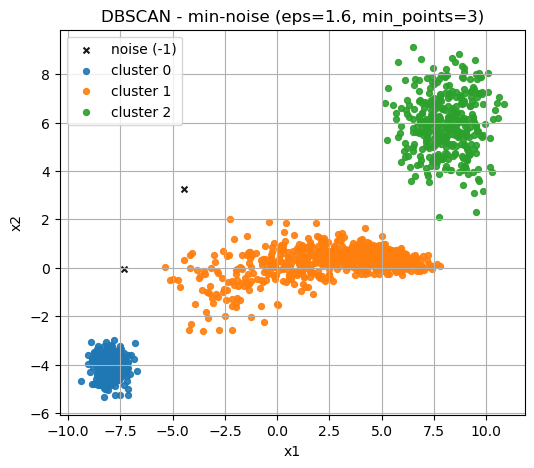

In [12]:
from sklearn.cluster import DBSCAN

# 0.8, 3 is first working value.
# 1.6, 3 is best.
EPS = 0.8  # epsilon=neighbourhood radius
MIN_POINTS = 3  # min_samples = min_points

EPS = 1.6  # epsilon=neighbourhood radius
MIN_POINTS = 3  # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)
plot_clustering_result(X, labels, title=f"DBSCAN - min-noise (eps={EPS}, min_points={MIN_POINTS})")


* EPS = 1.6
* MIN_POINTS = 3

There are many pairs of values which result in three clusters and two noise values. This was the earliest result in my search. Any 0.8 <= EPS <= 1.9 will produce 3 clusters. EPS = 2.0 allows the central cluster to jump across to the top right. There is no computational advantage to different EPS/MIN_POINTS values, so number of clusters and minimizing noise is the goal. The EPS value allows the central cluster to reach the weakly joined values on the left, and the single value between the middle and top-right to be labeled.

#### Densest-cores only

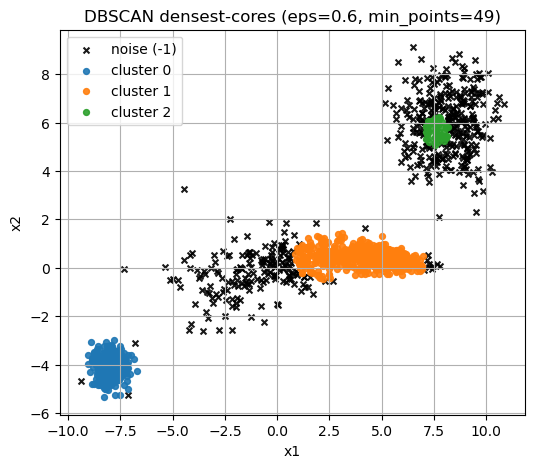

In [30]:

# Densest cores only
EPS = 0.6  # epsilon=neighbourhood radius
MIN_POINTS = 49  # min_samples = min_points

labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)
plot_clustering_result(X, labels, title=f"DBSCAN densest-cores (eps={EPS}, min_points={MIN_POINTS})")

* EPS = 0.6
* min_points = 49

These values favor dense cores because the density required to start a cluster is (by definition):

(min_points/(np.pi * eps**2))

or the number of points per unit area within a circle of radius EPS. To find the densest regions, EPS should be decreased while increasing min_points. This increases the density required for a cluster to start.

These values produce the 3 visible clusters, with a maximum density of 43.3.

EPS less than 0.3 did not find the three separate clusters, doubling up on either 2 in the middle, or 2 in the bottom left. The maximum density 3 cluster solution I found was (EPS=0.1, min_points=12), with a density of 382. However, the solution ignores the top-right cluster, finding two clusters in the bottom left and a third in the middle.